# EloSense v4: Chess Form Volatility

EloSense so far has been about predicting a player's rating band from a single game or a stack of aggregated games. This version asks a different question: not what a player's skill level is, but how erratic their performance currently is, separate from skill.

The idea comes straight out of quant finance. A stock's price level and its volatility are two different things you track separately, and volatility itself is treated as a hidden state that drifts over time, usually estimated with a stochastic volatility (SV) model fit by particle filtering. I'm applying that same machinery to chess: define a per-game "surprise" signal (did the player do better or worse than expected), treat the surprise's volatility as a hidden state `h_t`, and estimate `h_t` with a bootstrap particle filter plus Particle Marginal Metropolis-Hastings (PMMH) for the model parameters.

This reuses the same 60k-game Chess.com dataset and the player-disjoint split built in `elosense_v3.ipynb`, instead of starting over. Like v3, this notebook doesn't modify v1-v3, it re-derives whatever it needs from the cached features.

Sections below follow the W1-W5 work breakdown I used to plan this: data audit, observation signal, particle filter + PMMH (including the hierarchical extension), feature ablation against the existing v1-v3 model, and a correlation/trend pass at the end.

## W1. Sequencing and data audit

### 1. Chronological game ordering per player

The dataset has one row per game with a `white_id` and `black_id`, not one row per player-game in time order. To build a volatility path for a player I need their games sorted by when they were actually played, from either side of the board.

The PGN text embeds `UTCDate` and `UTCTime` tags, so I pull those out with a regex instead of relying on row order in the CSV (row order turns out to already be roughly chronological per player, but I don't want to depend on that).

In [1]:
import pandas as pd
import numpy as np
import re

DATE_RE = re.compile(r'\[UTCDate "([\d.]+)"\]')
TIME_RE = re.compile(r'\[UTCTime "([\d:]+)"\]')

RESULT_TO_SCORE = {
    "win": 1.0, "checkmated": 0.0, "agreed": 0.5, "repetition": 0.5,
    "stalemate": 0.5, "insufficient": 0.5, "50move": 0.5, "timevsinsufficient": 0.5,
    "abandoned": 0.0, "resigned": 0.0, "timeout": 0.0, "kingofthehill": 0.0,
    "threecheck": 0.0,
}

df = pd.read_csv("../data/club_games_data.csv")
print(f"rows: {len(df)}")

def player_history(pid, df=df):
    """Full chronological game log for one player, either side of the board."""
    mask = (df["white_id"] == pid) | (df["black_id"] == pid)
    sub = df.loc[mask].copy()
    is_white = (sub["white_id"] == pid).values
    sub["player_rating"] = np.where(is_white, sub["white_rating"], sub["black_rating"])
    sub["opp_rating"] = np.where(is_white, sub["black_rating"], sub["white_rating"])
    result = np.where(is_white, sub["white_result"], sub["black_result"])
    sub["actual_score"] = pd.Series(result, index=sub.index).map(RESULT_TO_SCORE)

    dates = sub["pgn"].str.extract(DATE_RE)[0]
    times = sub["pgn"].str.extract(TIME_RE)[0]
    sub["dt"] = pd.to_datetime(dates + " " + times, format="%Y.%m.%d %H:%M:%S")
    sub = sub.sort_values("dt").reset_index(drop=True)

    sub["expected_score"] = 1.0 / (1.0 + 10 ** ((sub["opp_rating"] - sub["player_rating"]) / 400.0))
    sub["x"] = sub["actual_score"] - sub["expected_score"]
    return sub[["dt", "player_rating", "opp_rating", "actual_score", "expected_score", "x", "time_class", "rated"]]

# sanity check on the most active player in the dataset
sample_pid = "https://api.chess.com/pub/player/aalisyed"
h = player_history(sample_pid)
print(f"{sample_pid}: {len(h)} games, {h['dt'].min()} to {h['dt'].max()}")
assert h["dt"].is_monotonic_increasing, "sort failed"
assert h["x"].isna().sum() == 0, "unmapped result code found"
h.head()

rows: 66879
https://api.chess.com/pub/player/aalisyed: 2253 games, 2021-05-03 21:10:10 to 2021-05-26 03:17:10


,dt,player_rating,opp_rating,actual_score,expected_score,x,time_class,rated
0,2021-05-03 21:10:10,1733,1566,1.0,0.723388,0.276612,bullet,True
1,2021-05-03 21:13:14,1738,1588,1.0,0.703385,0.296615,bullet,True
2,2021-05-03 21:15:21,1732,1819,0.0,0.377350,-0.377350,bullet,True
3,2021-05-03 21:17:47,1736,1556,1.0,0.738109,0.261891,bullet,True
4,2021-05-03 21:20:33,1725,1619,0.0,0.647983,-0.647983,bullet,True


### 2. Games-per-player distribution

Before writing any particle filter code I want to know whether there's enough per-player history for single-player estimation to even make sense. PMMH needs a decent-length time series to pin down `mu`, `phi`, `sigma_eta` for one player; if most players only have a handful of games, that's not going to work and the hierarchical version stops being an optional extension.

total players: 56234
count    56234.000000
mean         2.378597
std         21.796769
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max       2253.000000
Name: count, dtype: float64

quantiles:
0.50     1.0
0.75     1.0
0.90     2.0
0.95     3.0
0.99    16.0
Name: count, dtype: float64

players with >= 10 games: 803
players with >= 20 games: 505
players with >= 50 games: 281
players with >= 100 games: 158
players with >= 200 games: 86


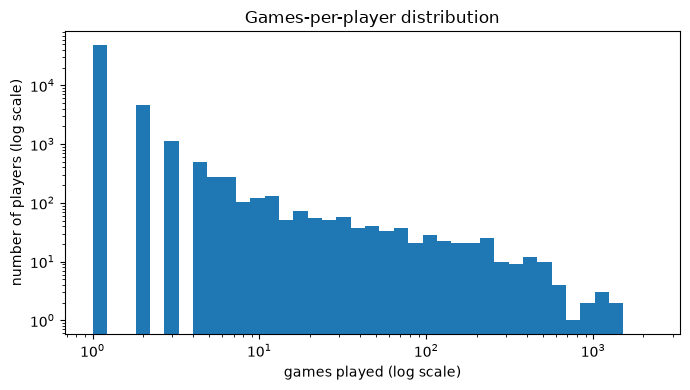

In [2]:
import matplotlib.pyplot as plt

game_counts = pd.concat([df["white_id"], df["black_id"]]).value_counts()

print(f"total players: {len(game_counts)}")
print(game_counts.describe())
print()
print("quantiles:")
print(game_counts.quantile([0.5, 0.75, 0.9, 0.95, 0.99]))
print()
for n in [10, 20, 50, 100, 200]:
    print(f"players with >= {n} games: {(game_counts >= n).sum()}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(game_counts, bins=np.logspace(0, np.log10(game_counts.max()), 40))
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("games played (log scale)")
ax.set_ylabel("number of players (log scale)")
ax.set_title("Games-per-player distribution")
plt.tight_layout()
plt.savefig("../images/v4_games_per_player.png", dpi=120)
plt.show()

### 3. Pooling decision

Median is 1 game per player, 75th percentile is still 1. That's not a long tail problem I can wave away, it's the whole distribution. A single-player PMMH run needs a real time series to estimate `mu`, `phi`, `sigma_eta` from, and a player with 1-3 games gives the sampler almost nothing to work with; the likelihood surface would be flat and the posterior would just fall back to the prior.

So the hierarchical model (checklist items 13-18) isn't a stretch goal here, it's required for the model to say anything useful about the typical player. Only 281 players have 50+ games and 505 have 20+, everyone else has to borrow strength from the population.

That said, I still want a single well-represented player to build and debug the plain (non-hierarchical) particle filter and PMMH on first, since debugging a hierarchical sampler on top of a filter I haven't verified yet is asking for trouble. Two players stood out while scanning the top of the games-per-player list:

- **aalisyed**, 2,253 games, all inside a 23-day window in May 2021 (looks like a rapid/blitz binge, not daily games). Rolling 20-game win rate swings from 85% down to 15%, and there's a 13-game losing streak starting 2021-05-12. That's exactly the kind of visible slump I want for the event-study section, so this becomes the single-player build-and-debug case.
- **51fun**, 1,298 games. One game in March 2020, then nothing for 424 days, then a burst of ~1,297 games in May 2021. This is the case for the irregular-timing problem the PRD talks about: a real, large gap in a real player's history, not a synthetic one. I'm flagging it now for the event-study section even though the checklist's core PMMH work (items 7-18) treats time as game-indexed, not calendar time — the OU-based continuous-time version is scoped as a later extension, not part of this v4 checklist.

## W2. Observation signal

### 4. Aggregate CPL features to per-game surprise signal

The PRD's Option B (engine-based deviation) is the richer surprise signal: how far a player's moves deviate from Stockfish's top choice, rather than just win/draw/loss against expectation. v3 already has `features/cpl_features_v3.csv`, average centipawn loss per move for a sample of games. I wanted to check first whether that sample is dense enough, per player, to build a volatility time series on, before committing to it as the main observation signal.

In [3]:
import json

cpl = pd.read_csv("../features/cpl_features_v3.csv")
cpl["cpl_list"] = cpl["cpl_list"].apply(lambda s: json.loads(s) if isinstance(s, str) else None)
cpl = cpl.dropna(subset=["cpl_list"]).reset_index(drop=True)
cpl["cpl_mean"] = cpl["cpl_list"].apply(np.mean)

# row_id indexes back into the full club_games_data.csv
game_ids = df.loc[cpl["row_id"]]
cpl_players = pd.concat([game_ids["white_id"], game_ids["black_id"]])
cpl_counts = cpl_players.value_counts()

print(f"CPL sample covers {len(cpl)} games, touching {len(cpl_counts)} distinct players")
print(cpl_counts.describe())
print(f"players with >= 5 CPL-scored games: {(cpl_counts >= 5).sum()}")
print(f"players with >= 10 CPL-scored games: {(cpl_counts >= 10).sum()}")

CPL sample covers 7723 games, touching 8522 distinct players
count    8522.000000
mean        1.812485
std         4.560799
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max       167.000000
Name: count, dtype: float64
players with >= 5 CPL-scored games: 441
players with >= 10 CPL-scored games: 226


**Dead end.** The CPL sample was built for the v3 classifier (8,000 games sampled roughly evenly across train/test, not sampled per-player), so per-player coverage is thin: median 1 CPL-scored game per player, and only 234 players even reach 10 scored games. Worse, those 10 games for a given player aren't consecutive, they're whichever games happened to land in the random sample, so even a player with 10 scored games doesn't have a usable contiguous `x_t` sequence, it has 10 isolated points with unscored games in between.

Getting a dense enough CPL signal would mean re-running Stockfish over full per-player histories instead of a random sample, which is exactly the multi-hour multiprocess job v3's W3 section describes for the full dataset. Not doing that here. Going with the Elo-residual signal (Option A) as the primary observation for the rest of this notebook, and leaving engine-based deviation as a real option for a future pass if there's time to run the engine over specific players' full histories instead of a random sample.

### 5. Elo-residual observation signal

`player_history()` from W1 already computes this (`x = actual_score - expected_score`), so there's no new pipeline to build, just confirming it's well-behaved as an observation for the SV model. `expected_score` comes straight from the logistic Elo formula, `actual_score` is 1/0.5/0 from `RESULT_TO_SCORE`. `x_t` sits in [-1, 1] and should hover near 0 for a player performing at their rating.

In [4]:
expected_white = 1.0 / (1.0 + 10 ** ((df["black_rating"] - df["white_rating"]) / 400.0))
actual_white = df["white_result"].map(RESULT_TO_SCORE)
x_all = actual_white - expected_white

print(f"x_t over all {len(x_all)} games (white side only, for a quick global sanity check):")
print(x_all.describe())
print(f"NaN count: {x_all.isna().sum()}")

x_t over all 66879 games (white side only, for a quick global sanity check):
count    66879.000000
mean         0.015298
std          0.452709
min         -0.999759
25%         -0.451226
50%          0.036222
75%          0.459792
max          0.999505
dtype: float64
NaN count: 0


### 6. Sanity-check the surprise signal

Global distribution first, then a look at the two flagged players from W1 to make sure `player_history()` produces something sane on real per-player sequences, not just in aggregate.

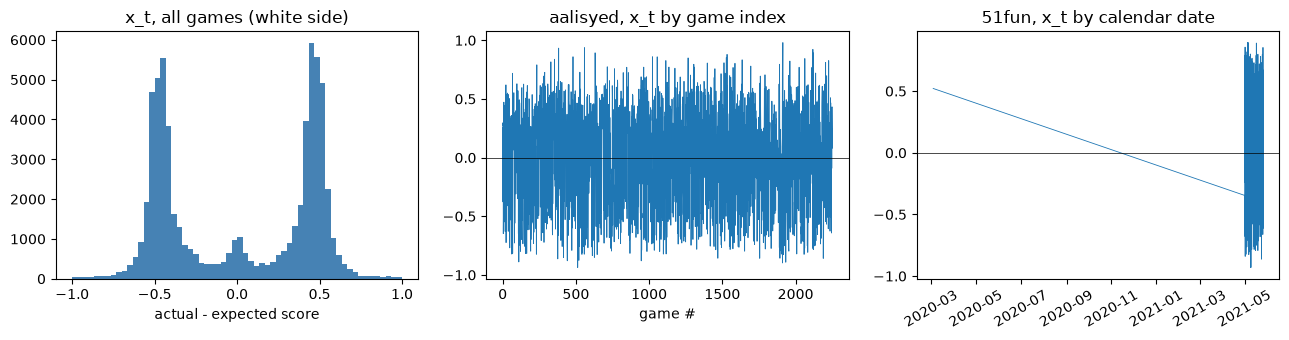

aalisyed x_t: {'mean': -0.0027490394061009255, 'std': 0.44160536218488716, 'min': -0.936673124689052, 'max': 0.9805477980915619}
51fun x_t: {'mean': -0.0015644091716477979, 'std': 0.4517498075506453, 'min': -0.9302417126410938, 'max': 0.8937746801781464}


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))

axes[0].hist(x_all.dropna(), bins=60, color="steelblue")
axes[0].set_title("x_t, all games (white side)")
axes[0].set_xlabel("actual - expected score")

h_aalisyed = player_history("https://api.chess.com/pub/player/aalisyed")
axes[1].plot(h_aalisyed["x"].values, lw=0.6)
axes[1].axhline(0, color="black", lw=0.5)
axes[1].set_title("aalisyed, x_t by game index")
axes[1].set_xlabel("game #")

h_51fun = player_history("https://api.chess.com/pub/player/51fun")
axes[2].plot(h_51fun["dt"], h_51fun["x"].values, lw=0.6)
axes[2].axhline(0, color="black", lw=0.5)
axes[2].set_title("51fun, x_t by calendar date")
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("../images/v4_surprise_signal.png", dpi=120)
plt.show()

print("aalisyed x_t:", h_aalisyed["x"].describe()[["mean", "std", "min", "max"]].to_dict())
print("51fun x_t:", h_51fun["x"].describe()[["mean", "std", "min", "max"]].to_dict())

Both look like what I'd expect: centered close to 0, bounded in [-1, 1], no obvious data issues. The 51fun plot by calendar date makes the 424-day gap from March 2020 to May 2021 visible directly in the x-axis, which is the whole reason game-indexing throws this information away.